In [1]:
#  Import libraries and load the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Machine-learning imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Project paths
project_root = Path.home() / "Desktop" / "MajorProject_Bindu BS"
data_path = project_root / "data" / "student_performance.csv"

# Load dataset
df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [3]:
# Cell 2: Select features and target variable

# StudentID is only an identifier.
# GradeClass is derived from GPA, so it is excluded to prevent data leakage.
# GPA is the target variable that the model will predict.

X = df.drop(columns=["StudentID", "GPA", "GradeClass"])
y = df["GPA"]

print("Input feature columns:")
print(X.columns.tolist())

print("\nNumber of input features:", X.shape[1])
print("Target variable:", y.name)
print("Target variable range:", y.min(), "to", y.max())

Input feature columns:
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

Number of input features: 12
Target variable: GPA
Target variable range: 0.0 to 4.0


In [5]:
#  Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training feature data shape:", X_train.shape)
print("Testing feature data shape:", X_test.shape)
print("Training target data shape:", y_train.shape)
print("Testing target data shape:", y_test.shape)

print("\nTraining data percentage:", round(len(X_train) / len(X) * 100, 1), "%")
print("Testing data percentage:", round(len(X_test) / len(X) * 100, 1), "%")

Training feature data shape: (1913, 12)
Testing feature data shape: (479, 12)
Training target data shape: (1913,)
Testing target data shape: (479,)

Training data percentage: 80.0 %
Testing data percentage: 20.0 %


In [6]:
#  Train the Linear Regression model

model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [7]:
#  Make predictions and evaluate model performance

# Predict GPA for the unseen test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance on Test Data")
print("-" * 35)
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R²) Score: {r2:.3f}")

Model Performance on Test Data
-----------------------------------
Mean Absolute Error (MAE): 0.155
Root Mean Squared Error (RMSE): 0.197
R-squared (R²) Score: 0.953


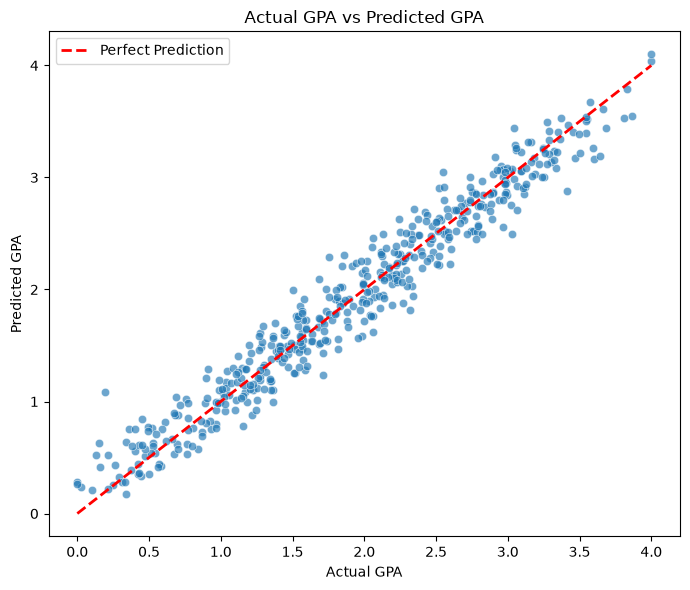

Graph saved in: C:\Users\ADMIN\Desktop\MajorProject_Bindu BS\screenshots\actual_vs_predicted_gpa.png


In [8]:
# Cell 6: Visualize actual GPA versus predicted GPA

plt.figure(figsize=(7, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.65)

# Reference line: perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual GPA vs Predicted GPA")
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.legend()
plt.tight_layout()

# Save graph for documentation
plot_path = project_root / "screenshots" / "actual_vs_predicted_gpa.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print("Graph saved in:", plot_path)

In [9]:
# Cell 7: Feature importance using Linear Regression coefficients

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# Sort by absolute coefficient value
feature_importance["AbsoluteCoefficient"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values(
    by="AbsoluteCoefficient",
    ascending=False
)

print("Feature importance based on Linear Regression coefficients:")
feature_importance[["Feature", "Coefficient"]]

Feature importance based on Linear Regression coefficients:


,Feature,Coefficient
6,Tutoring,0.258262
8,Extracurricular,0.189546
9,Sports,0.184991
10,Music,0.152484
7,ParentalSupport,0.147838
5,Absences,-0.099517
4,StudyTimeWeekly,0.029039
1,Gender,0.010516
0,Age,-0.005734
11,Volunteering,-0.005282


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14268\98697998.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


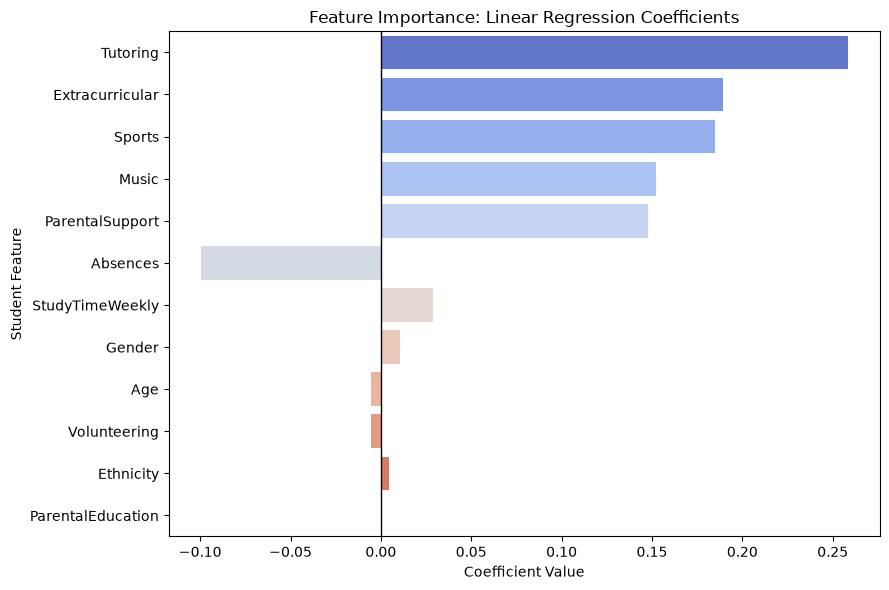

Feature importance graph saved in: C:\Users\ADMIN\Desktop\MajorProject_Bindu BS\screenshots\feature_importance.png


In [10]:
# Cell 8: Visualize feature importance

plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature",
    palette="coolwarm"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Feature Importance: Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Student Feature")
plt.tight_layout()

# Save graph for documentation
plot_path = project_root / "screenshots" / "feature_importance.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print("Feature importance graph saved in:", plot_path)